# Model Training


In [83]:
# importing required data and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#modelling
from sklearn.metrics import mean_absolute_error, r2_score, median_absolute_error, mean_squared_error, make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import RandomizedSearchCV, train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import joblib
import warnings


In [ ]:
# importing the csv file as dataframe
try:
    df = pd.read_csv("data/preprocessed/preprocessed.csv")
except:
    df = pd.read_csv("preprocessed.csv")



In [ ]:
df = df.drop(columns=['id'], axis=1)

In [ ]:
df.head()

In [ ]:
target = "accident_risk"

In [76]:
# --- PREPARING X AND Y VARIABLES---
X = df.drop(columns=[target], axis=1)
X.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,speed_risk_band,high_curvature,lane_complexity,accident_density,poor_visibility
0,urban,2,0.06,35,daylight,rainy,0,1,afternoon,0,1,1,low,0,0.12,0.333333,0
1,urban,4,0.99,35,daylight,clear,1,0,evening,1,1,0,low,1,3.96,0.000000,0
2,rural,4,0.63,70,dim,clear,0,1,morning,1,0,2,medium,1,2.52,0.400000,0
3,highway,4,0.07,35,dim,rainy,1,1,morning,0,0,1,low,0,0.28,0.200000,0
4,rural,1,0.58,60,daylight,foggy,0,0,evening,1,0,1,medium,0,0.58,0.500000,0


In [ ]:
X.head()

In [ ]:
Y = df[target]
Y.head()

In [ ]:
numerical_features = [
    "num_lanes",
    "curvature",
    "speed_limit",
    "lane_complexity"      # SAFE
]

categorical_features = [
    "road_type",
    "lighting",
    "weather",
    "time_of_day",
    "speed_risk_band"      # SAFE engineered category
]


boolean_features = [
    "road_signs_present",
    "public_road",
    "holiday",
    "school_season",
    "high_curvature",      # SAFE
    "poor_visibility"      # SAFE
]

In [ ]:
df['school_season']

In [ ]:
df[boolean_features] = df[boolean_features].astype(int)


In [ ]:
df.head()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[

        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_features),
        ('bool', "passthrough", boolean_features)
    ]
)



In [ ]:
preprocessor


In [ ]:

X = preprocessor.fit_transform(X)

In [ ]:
X.shape

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("x_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train_shape", y_train.shape)
print("y_test shape:", y_test.shape)

In [ ]:
# create an evaluate function to evaluate models
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [47]:
models = {
    'linear_regression': LinearRegression(),
    'lasso_regression': Lasso(),
    'Ridge_regression': Ridge(),
    'KNN_regressor': KNeighborsRegressor(),
    'Decision_tree_regressor': DecisionTreeRegressor(),
    'Random_forest_regressor': RandomForestRegressor(),
    'XGB_regressor': XGBRegressor(),
    'cat_boost_regressor': CatBoostRegressor(),
    'Ada_boost_regressor': AdaBoostRegressor()
}

model_report = [] # to store model evaluation reports
r2_list = [] # to store r2 scores of different models
rmse_list = [] # to store rmse of different models

for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_report.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

linear_regression
Model performance for Training set
- Root Mean Squared Error: 0.0627
- Mean Absolute Error: 0.0484
- R2 Score: 0.8583
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.0628
- Mean Absolute Error: 0.0485
- R2 Score: 0.8572


lasso_regression
Model performance for Training set
- Root Mean Squared Error: 0.1665
- Mean Absolute Error: 0.1330
- R2 Score: 0.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.1662
- Mean Absolute Error: 0.1327
- R2 Score: -0.0000


Ridge_regression
Model performance for Training set
- Root Mean Squared Error: 0.0627
- Mean Absolute Error: 0.0484
- R2 Score: 0.8583
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.0628
- Mean Absolute Error: 0.0485
- R2 Score: 0.8572


KNN_regressor
Model performance for Training set
- Root Mean Squared Error: 0.0565
- Mean Absolute Error: 0.0438
- R2 Score: 0.8849
--------

In [64]:
# result dataframe

result_df= pd.DataFrame(list(zip(model_report, r2_list, rmse_list)), columns=['Model', 'R2_score', 'RMSE']).sort_values(by='R2_score', ascending=False)
result_df

,Model,R2_score,RMSE


In [57]:
Linear_regression = LinearRegression()
Linear_regression.fit(X_train, y_train)
linear_regression_pred = Linear_regression.predict(X_test)
score = r2_score(y_test, linear_regression_pred)*100

print("R2 score for linear regression is: ", score)




R2 score for linear regression is:  85.71548571874254


In [ ]:
# cross valdation for catboost

rmse_scorer = make_scorer(mean_squared_error, squared=False)

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    verbose=0,
    random_state=42
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cat_rmse = cross_val_score(
    
    cat_model,
    X_train,
    y_train,
    scoring=rmse_scorer,
    cv=cv
)

print("CatBoost CV RMSE:", cat_rmse.mean(), "±", cat_rmse.std())


CatBoost CV RMSE: 0.06137656184247153 ± 0.00022978592791097458


In [60]:
# cross validation for xgboost
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_rmse = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    scoring=rmse_scorer,
    cv=cv
)

print("XGBoost CV RMSE:", xgb_rmse.mean(), "±", xgb_rmse.std())


XGBoost CV RMSE: 0.0612582667124502 ± 0.00021564292661199343


In [61]:
# hyperparmeter tuning for catboost
cat_param_grid = {
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "iterations": [300, 500, 800],
    "l2_leaf_reg": [1, 3, 5, 7]
}

cat_search = RandomizedSearchCV(
    CatBoostRegressor(
        loss_function="RMSE",
        verbose=0,
        random_state=42
    ),
    param_distributions=cat_param_grid,
    n_iter=20,
    scoring=rmse_scorer,
    cv=5,
    n_jobs=-1
)

cat_search.fit(X_train, y_train)

print("Best CatBoost params:", cat_search.best_params_)
print("Best CV RMSE:", cat_search.best_score_)


Best CatBoost params: {'learning_rate': 0.01, 'l2_leaf_reg': 1, 'iterations': 300, 'depth': 8}
Best CV RMSE: 0.062410848560980836


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


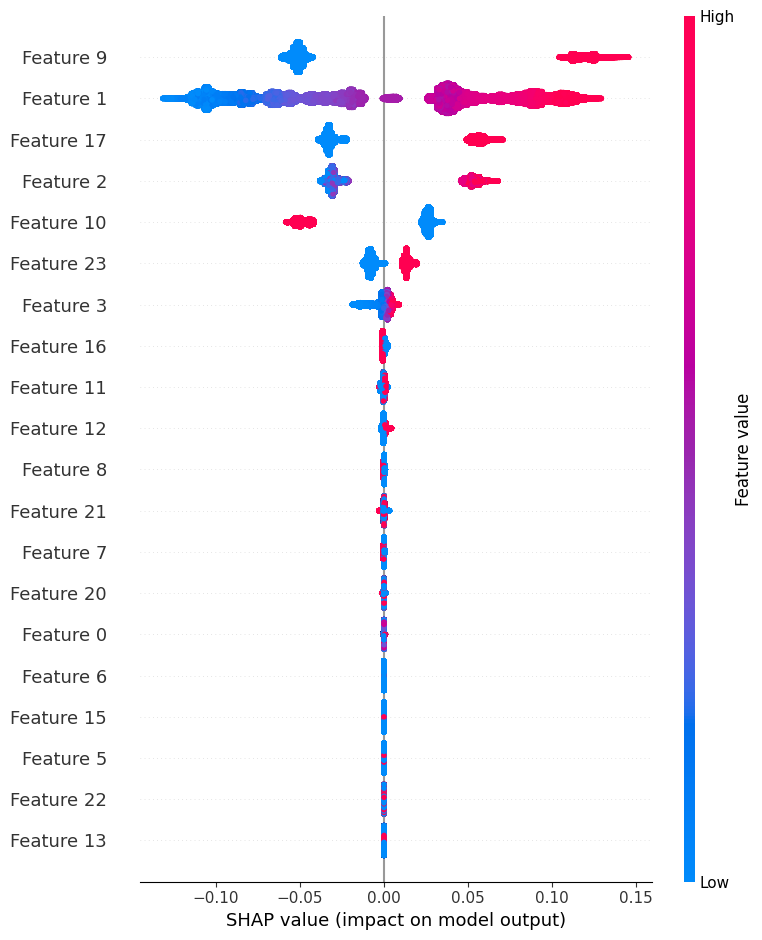

In [67]:
import shap

explainer = shap.TreeExplainer(cat_model_best)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)


In [78]:
# lets retrain on the best parameter

final_cat_model = CatBoostRegressor(
    learning_rate=0.01,
    iterations=300,
    depth=8,
    l2_leaf_reg=1,
    loss_function="RMSE",
    random_state=42,
    verbose=100
)

final_cat_model.fit(X_train, y_train)



0:	learn: 0.1650648	total: 98.6ms	remaining: 29.5s
100:	learn: 0.0843196	total: 9.47s	remaining: 18.7s
200:	learn: 0.0656064	total: 18.5s	remaining: 9.09s
299:	learn: 0.0623729	total: 29.1s	remaining: 0us


In [79]:
y_pred = final_cat_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("best rnse value: ", rmse)
print("best r2 value: ", r2)

best rnse value:  0.0625428764558663
best r2 value:  0.8583375389185114


In [88]:
import os

os.makedirs("artifacts", exist_ok=True)


In [89]:
joblib.dump(final_cat_model, "artifacts/final_catboost_model.pkl")
joblib.dump(preprocessor, "artifacts/preprocessor.pkl")

['artifacts/preprocessor.pkl']